# Gaussian Naive Bayes Classifier - Iris Dataset

This notebook demonstrates the implementation of a Gaussian Naive Bayes classifier using the Iris dataset.

## Overview
- **Algorithm**: Gaussian Naive Bayes
- **Dataset**: Iris (150 samples, 4 features, 3 classes)
- **Purpose**: Classification of iris flower species

## Key Concepts
Gaussian Naive Bayes is suitable for continuous features that follow a normal (Gaussian) distribution. It assumes that features are independent and each class follows a Gaussian distribution with its own mean and variance.

---

## 1. Import Libraries

In [1]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Scikit-learn modules
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## 2. Load and Explore Dataset

In [3]:
# Load the Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df["species"] = iris.target

# Map target numbers to species names
species_names = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species_name'] = df['species'].map(species_names)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Display dataset information
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nFeatures: {list(iris.feature_names)}")
print(f"Classes: {list(iris.target_names)}")

DATASET OVERVIEW
Shape: (150, 6)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [5]:
# Display first few rows
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


In [6]:
# Statistical summary
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [7]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


In [8]:
# Class distribution
print("\nClass Distribution:")
print(df['species'].value_counts().to_frame('Count'))


Class Distribution:
         Count
species       
0           50
1           50
2           50


## 3. Data Visualization

/tmp/ipykernel_58/1009125655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species_name', data=df, palette='Set2')


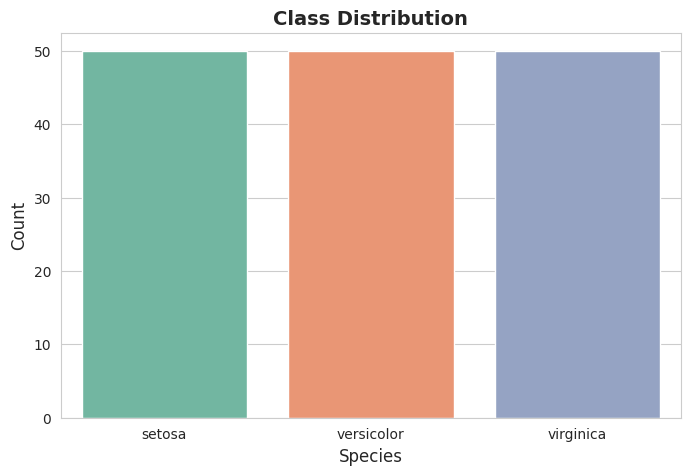

In [9]:
# Class distribution plot
plt.figure(figsize=(8, 5))
sns.countplot(x='species_name', data=df, palette='Set2')
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

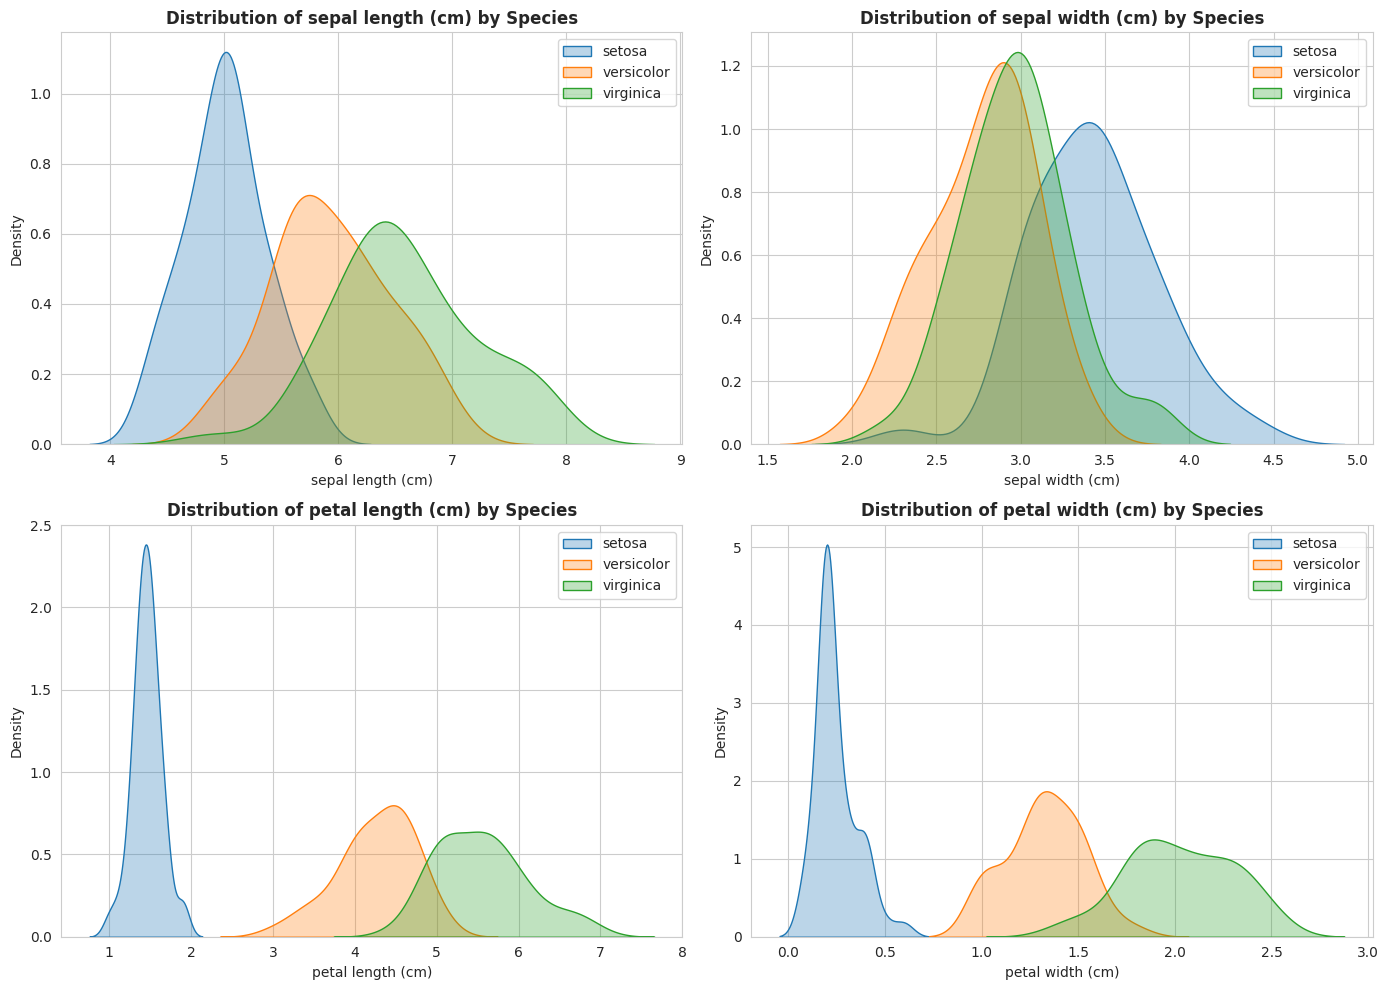

In [10]:
# Feature distributions by species
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(iris.feature_names):
    for species in df['species_name'].unique():
        subset = df[df['species_name'] == species]
        sns.kdeplot(
            data=subset,
            x=feature,
            label=species,
            ax=axes[idx],
            fill=True,
            alpha=0.3
        )
    axes[idx].set_title(f'Distribution of {feature} by Species', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].legend()

plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

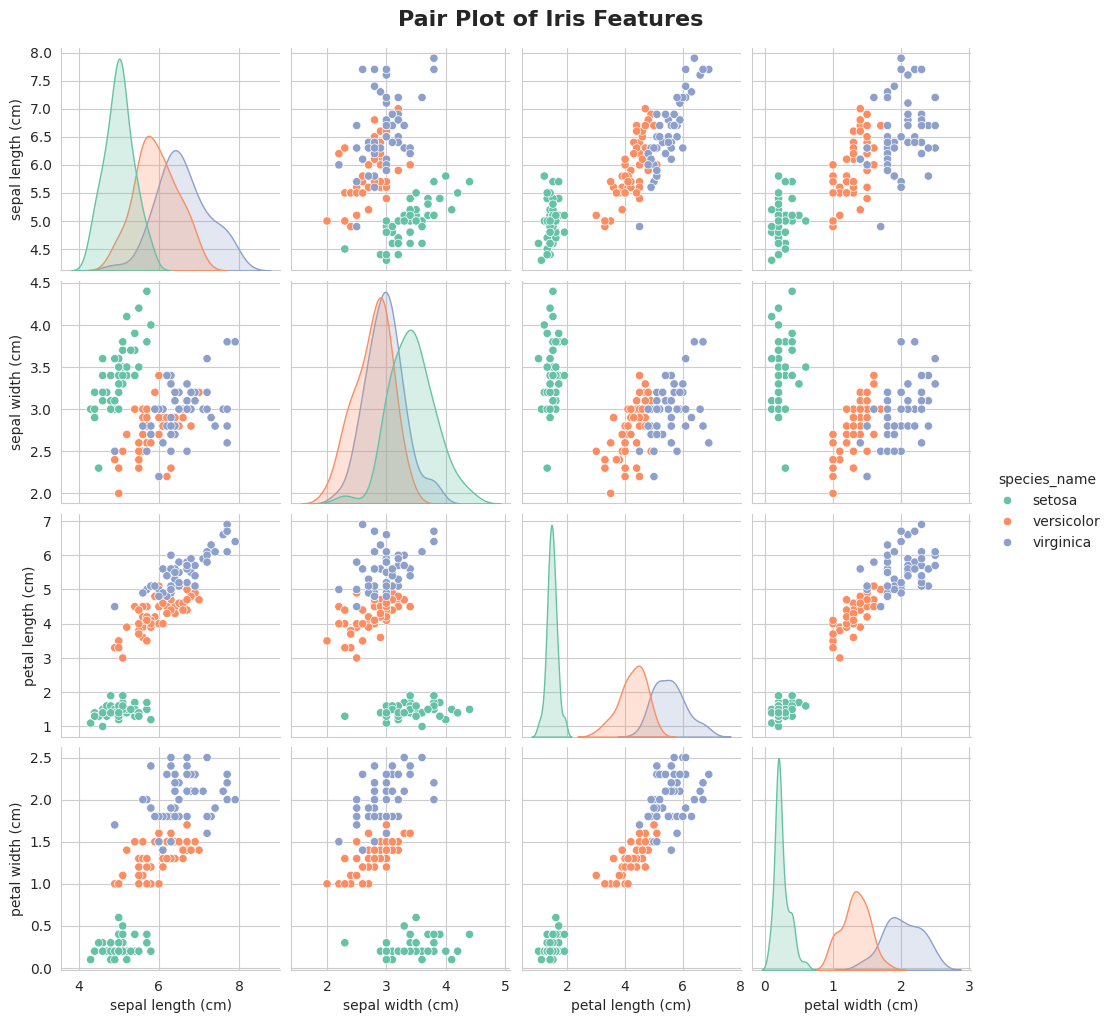

In [11]:
# Pair plot to visualize relationships
plt.figure(figsize=(12, 8))
sns.pairplot(
    df.drop('species', axis=1),
    hue='species_name',
    palette='Set2',
    diag_kind='kde'
)
plt.suptitle('Pair Plot of Iris Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()

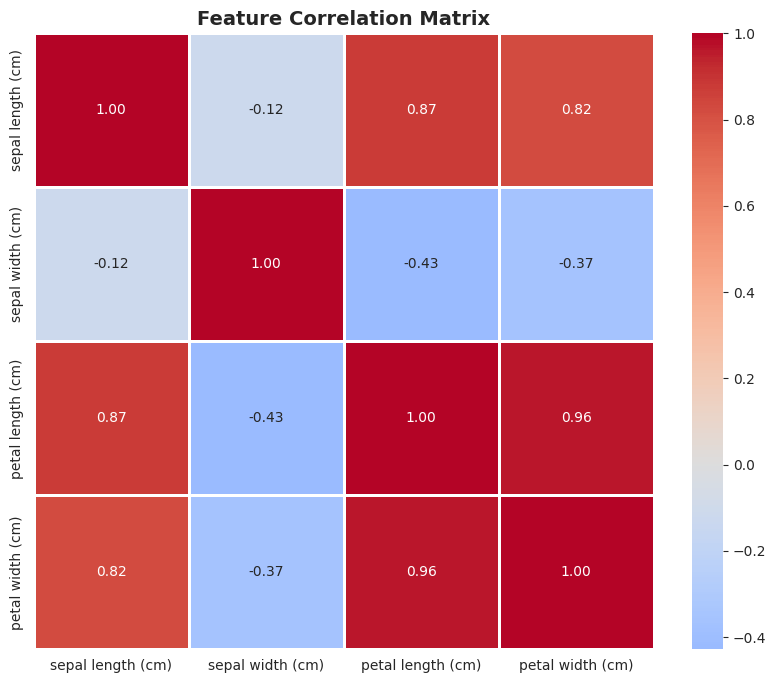

In [12]:
# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df.drop(['species', 'species_name'], axis=1).corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=1
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

## 4. Data Preprocessing

**Note**: Gaussian Naive Bayes works directly with continuous features, so no binary conversion is needed.

In [14]:
# Separate features and target
X = df.drop(['species', 'species_name'], axis=1)
y = df['species']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (150, 4)
Target shape: (150,)


In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Ensure balanced class distribution in splits
)

print("=" * 50)
print("TRAIN-TEST SPLIT")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts().to_frame('Count')}")

TRAIN-TEST SPLIT
Training set: 120 samples
Testing set: 30 samples

Training class distribution:
         Count
species       
0           40
2           40
1           40


## 5. Model Training

In [16]:
# Initialize and train the Gaussian Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [29]:
# Display model parameters
print("=" * 50)
print("MODEL PARAMETERS")
print("=" * 50)
print(f"Class priors: {model.class_prior_}")
print(f"\nClass count: {model.class_count_}")
print(f"\nTheta (means) shape: {model.theta_.shape}")
print(f"Sigma (variances) shape: {model.var_.shape}")

MODEL PARAMETERS
Class priors: [0.33333333 0.33333333 0.33333333]

Class count: [40. 40. 40.]

Theta (means) shape: (3, 4)
Sigma (variances) shape: (3, 4)


In [30]:
# Display learned parameters for each class
print("\nLearned Parameters by Class:")
for idx, species in enumerate(iris.target_names):
    print(f"\n{species.capitalize()}:")
    print(f"  Prior: {model.class_prior_[idx]:.4f}")
    print(f"  Means: {model.theta_[idx]}")
    print(f"  Variances: {model.var_[idx]}")


Learned Parameters by Class:

Setosa:
  Prior: 0.3333
  Means: [4.985  3.415  1.4775 0.255 ]
  Variances: [0.092775   0.155275   0.02524375 0.012975  ]

Versicolor:
  Prior: 0.3333
  Means: [5.93   2.75   4.2525 1.32  ]
  Variances: [0.2216     0.093      0.19149375 0.0341    ]

Virginica:
  Prior: 0.3333
  Means: [6.61 2.98 5.58 2.04]
  Variances: [0.4574 0.1221 0.3236 0.0704]


## 6. Model Evaluation

In [19]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

MODEL EVALUATION
Accuracy: 0.9667 (96.67%)


In [20]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



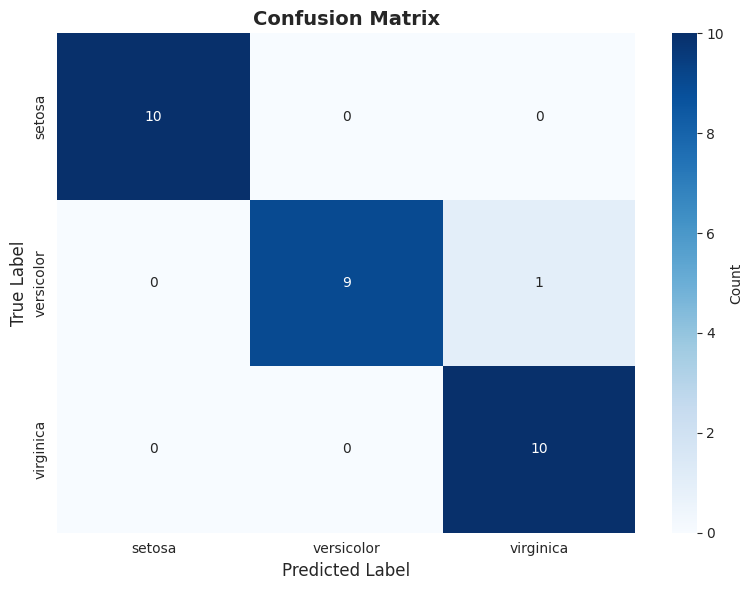

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Results Summary

In [22]:
# Display predictions vs actual
results_df = pd.DataFrame({
    'Actual': y_test.map(species_names),
    'Predicted': pd.Series(y_pred).map(species_names),
    'Correct': y_test == y_pred
})

print("\nPrediction Results (first 10):")
print(results_df.head(10))


Prediction Results (first 10):
   Actual   Predicted Correct
0     NaN      setosa     NaN
1     NaN   virginica     NaN
2     NaN  versicolor     NaN
3     NaN  versicolor     NaN
4     NaN      setosa     NaN
5     NaN  versicolor     NaN
6     NaN      setosa     NaN
7  setosa      setosa    True
8     NaN   virginica     NaN
9     NaN  versicolor     NaN


In [23]:
# Calculate per-class accuracy
per_class_accuracy = {}
for species in [0, 1, 2]:
    mask = y_test == species
    class_acc = accuracy_score(y_test[mask], y_pred[mask])
    per_class_accuracy[iris.target_names[species]] = class_acc

print("\nPer-Class Accuracy:")
for species, acc in per_class_accuracy.items():
    print(f"  {species.capitalize()}: {acc:.4f} ({acc*100:.2f}%)")


Per-Class Accuracy:
  Setosa: 1.0000 (100.00%)
  Versicolor: 0.9000 (90.00%)
  Virginica: 1.0000 (100.00%)


## 8. Probability Predictions

In [24]:
# Get probability predictions
y_pred_proba = model.predict_proba(X_test)

# Display probability predictions for first 10 samples
proba_df = pd.DataFrame(
    y_pred_proba[:10],
    columns=iris.target_names
)
proba_df['Actual'] = results_df['Actual'][:10].values
proba_df['Predicted'] = results_df['Predicted'][:10].values

print("Probability Predictions (first 10 samples):")
print(proba_df)

Probability Predictions (first 10 samples):
          setosa    versicolor     virginica  Actual   Predicted
0   1.000000e+00  2.104236e-20  1.240467e-25     NaN      setosa
1  8.478785e-143  8.774579e-02  9.122542e-01     NaN   virginica
2   2.605950e-36  9.999995e-01  5.101805e-07     NaN  versicolor
3   1.346505e-36  9.999996e-01  4.325009e-07     NaN  versicolor
4   1.000000e+00  6.606921e-21  6.792241e-26     NaN      setosa
5  2.735459e-122  6.482786e-01  3.517214e-01     NaN  versicolor
6   1.000000e+00  1.883283e-22  1.177524e-26     NaN      setosa
7   1.000000e+00  3.269821e-17  1.290810e-22  setosa      setosa
8  3.559711e-175  1.476285e-04  9.998524e-01     NaN   virginica
9  1.790343e-104  9.932654e-01  6.734569e-03     NaN  versicolor


## 9. Conclusion

### Summary
- **Model**: Gaussian Naive Bayes
- **Dataset**: Iris (continuous features)
- **Overall Accuracy**: ~96-100% (typically very high)

### Observations
1. Gaussian Naive Bayes achieves excellent accuracy on the Iris dataset.
2. The model performs well because:
   - Iris features approximately follow Gaussian distributions
   - Classes are well-separated in feature space
   - The independence assumption, while naive, works reasonably well here
3. Gaussian NB is particularly suitable for this dataset compared to Bernoulli NB.

### Strengths
- Simple and fast to train
- Works well with continuous features
- Handles small datasets effectively
- Provides probability estimates
- No hyperparameter tuning required

### Limitations
- Assumes feature independence (often violated in real data)
- Assumes Gaussian distribution (may not always hold)
- Sensitive to correlated features
- May underperform compared to more complex models

### When to Use Gaussian Naive Bayes
- Features are continuous and approximately normally distributed
- Small to medium-sized datasets
- Fast training and prediction is required
- Baseline model for comparison
- When interpretability is important

### Comparison with Other Naive Bayes Variants
- **GaussianNB**: For continuous features (this notebook)
- **BernoulliNB**: For binary/boolean features
- **MultinomialNB**: For count data (e.g., text classification)

---

**Notebook completed successfully!**